<a href="https://colab.research.google.com/github/raghusevva-boop/MY-RESUME/blob/main/LogisticRegressionSept.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

dataset link -- **https://drive.google.com/file/d/1ojl7p5cNhzAyYmuhMqtsQug2LCBBqi-G/view?usp=sharing**

# 1. Importing the libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/bank-additional-full (3) (1) (2).csv",sep =';')

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41199 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41195 non-null  float64
 1   job             41194 non-null  object 
 2   marital         41194 non-null  object 
 3   education       41194 non-null  object 
 4   default         41195 non-null  object 
 5   housing         41196 non-null  object 
 6   loan            41195 non-null  object 
 7   contact         41195 non-null  object 
 8   month           41196 non-null  object 
 9   day_of_week     41196 non-null  object 
 10  duration        41196 non-null  float64
 11  campaign        41196 non-null  float64
 12  pdays           41196 non-null  float64
 13  previous        41196 non-null  float64
 14  poutcome        41194 non-null  object 
 15  emp.var.rate    41196 non-null  float64
 16  cons.price.idx  41195 non-null  float64
 17  cons.conf.idx   41196 non-null 

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
# no of rows and columns

df.shape

(41199, 21)

In [ ]:
# names of columns
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41199 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41195 non-null  float64
 1   job             41194 non-null  object 
 2   marital         41194 non-null  object 
 3   education       41194 non-null  object 
 4   default         41195 non-null  object 
 5   housing         41196 non-null  object 
 6   loan            41195 non-null  object 
 7   contact         41195 non-null  object 
 8   month           41196 non-null  object 
 9   day_of_week     41196 non-null  object 
 10  duration        41196 non-null  float64
 11  campaign        41196 non-null  float64
 12  pdays           41196 non-null  float64
 13  previous        41196 non-null  float64
 14  poutcome        41194 non-null  object 
 15  emp.var.rate    41196 non-null  float64
 16  cons.price.idx  41195 non-null  float64
 17  cons.conf.idx   41196 non-null 

In [ ]:
# print random 10 rows from my dataset

df.sample(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
14035,52.0,unemployed,married,university.degree,unknown,no,yes,cellular,jul,fri,...,2.0,999.0,0.0,nonexistent,1.4,93.918,-42.7,4.963,5228.1,no
6528,42.0,unemployed,married,basic.9y,no,no,no,telephone,may,wed,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
25090,35.0,technician,married,university.degree,no,yes,no,cellular,nov,tue,...,2.0,999.0,0.0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
142,39.0,management,married,university.degree,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
15836,24.0,blue-collar,married,basic.9y,no,no,no,telephone,jul,mon,...,1.0,999.0,0.0,nonexistent,1.4,93.918,-42.7,4.960,5228.1,no
8778,30.0,blue-collar,single,unknown,no,no,no,telephone,jun,thu,...,1.0,999.0,0.0,nonexistent,1.4,94.465,-41.8,4.866,5228.1,no
13409,34.0,admin.,married,high.school,no,no,no,cellular,jul,wed,...,5.0,999.0,0.0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,yes
2654,44.0,entrepreneur,divorced,university.degree,no,yes,no,telephone,may,tue,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.856,5191.0,no
11924,42.0,management,married,high.school,no,no,no,telephone,jun,fri,...,5.0,999.0,0.0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
1438,38.0,technician,married,university.degree,unknown,no,no,telephone,may,thu,...,2.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no


In [ ]:
# different jobs and number of people doing the particular job

df['job'].value_counts()

,count
job,
admin.,10422
blue-collar,9254
technician,6743
services,3969
management,2924
retired,1726
entrepreneur,1456
self-employed,1421
housemaid,1060


In [ ]:
# 8:42 -- run a loop and print the categories of all object type columns

for col in df.columns:
  if df[col].dtype == 'object':
    print(df[col].value_counts())
    print()

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1726
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

marital
married     24934
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5249
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

default
no         32595
unknown     8597
yes            3
Name: count, dtype: int64

housing
yes        21584
no         18622
unknown      990
Name: count, dtype: int64

loan
no         33957
yes         6248
unknown      990
Name: count, dtype: int64

contact
cellular     26151
telephone    15044
Name: count, dty

In [ ]:
df.isnull().sum()

,0
age,4
job,5
marital,5
education,5
default,4
housing,3
loan,4
contact,4
month,3
day_of_week,3


In [ ]:
df.isnull().sum().sum()

np.int64(76)

In [ ]:
df.dropna(inplace = True)

In [ ]:
df.shape

(41190, 21)

In [ ]:
# checking the duplicates

df.duplicated().sum()

np.int64(13)

In [ ]:
# remove the duplicates

In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
df.shape

(41177, 21)

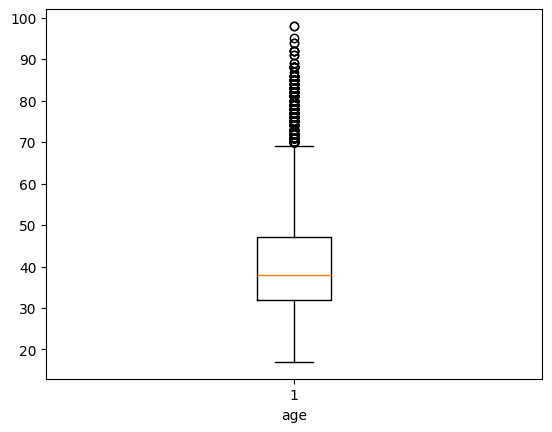

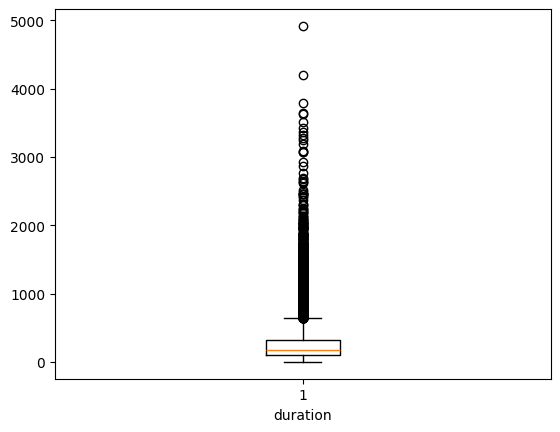

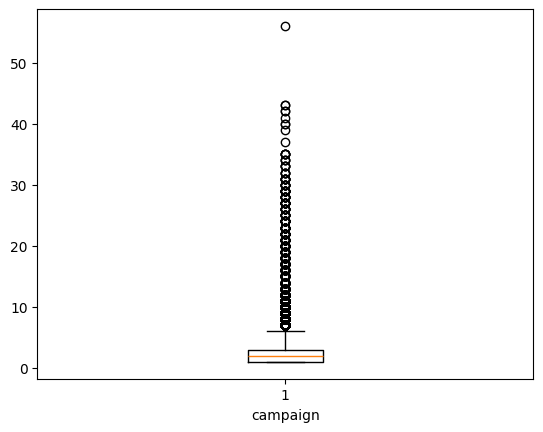

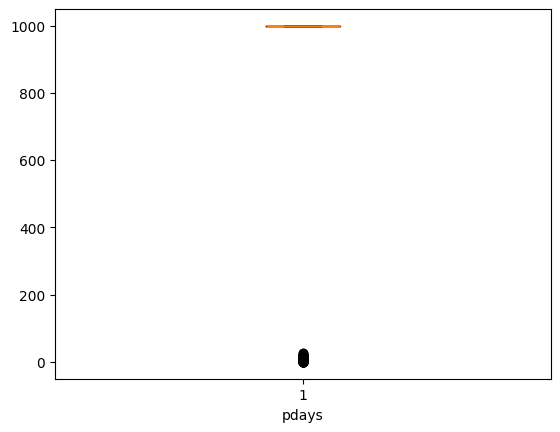

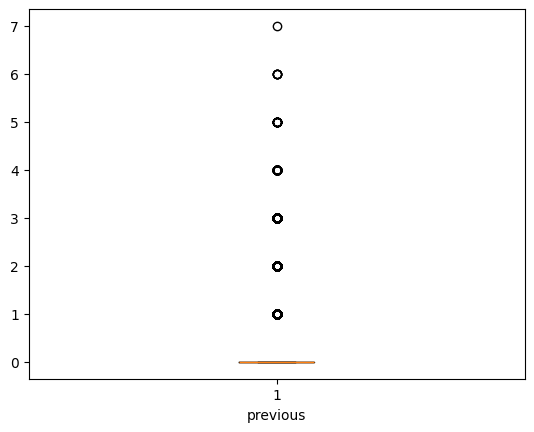

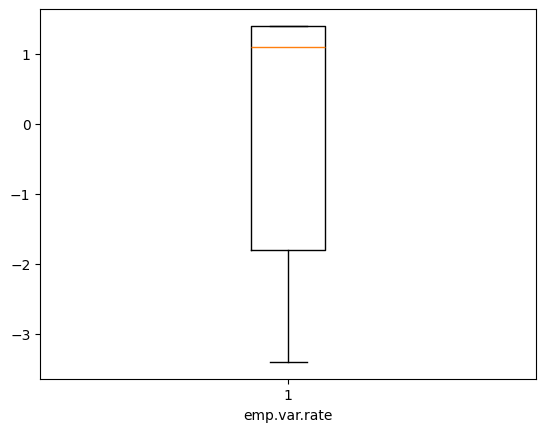

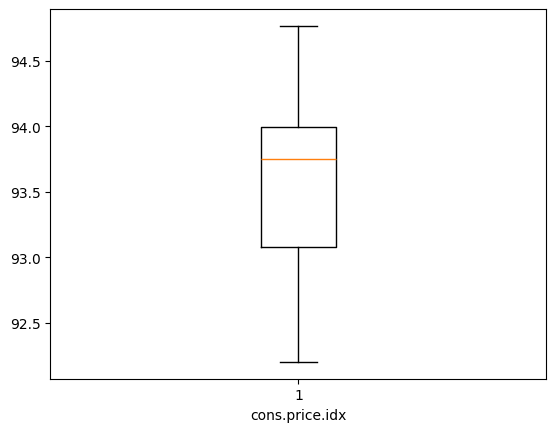

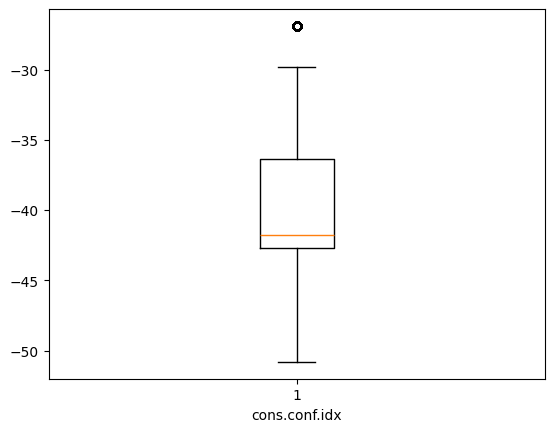

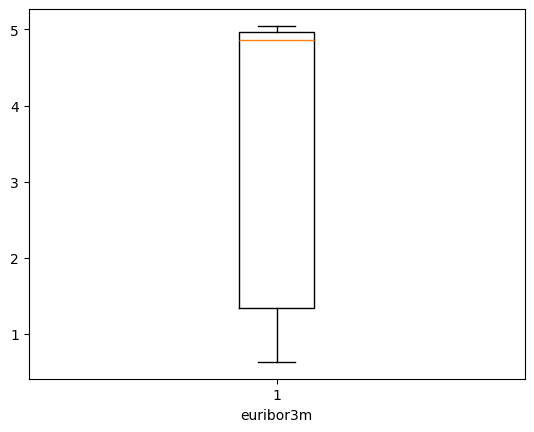

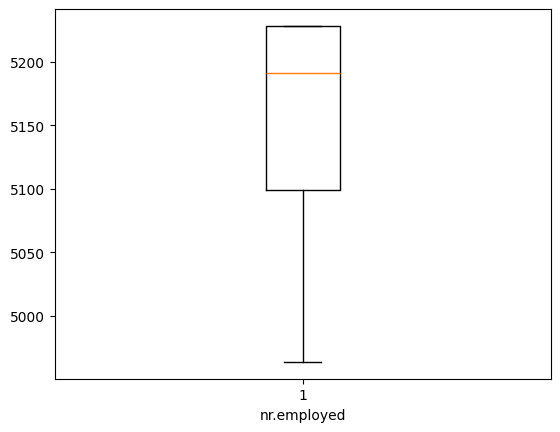

In [ ]:
for col in df.columns:
  if df[col].dtype !='object':
    plt.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

In [ ]:
# #duration  -- how to remove outliers
# 1. calculate q1 and q3
# 2. calculate iqr
# 3. calculate ul and ll
# 4. filter the data on the basis of ul and ll

# iqr -- inter quartile range

q1 = df['duration'].quantile(0.25)

In [ ]:
q1

np.float64(102.0)

In [ ]:
q3 = df['duration'].quantile(0.75)

In [ ]:
q3

np.float64(319.0)

In [ ]:
iqr = q3 - q1

In [ ]:
ul = q3 + 1.5*iqr
ll = q1 - 1.5*iqr

In [ ]:
ul

np.float64(644.5)

In [ ]:
ll

np.float64(-223.5)

In [ ]:
df = df[(df['duration']>=ll) & (df['duration']<=ul)]

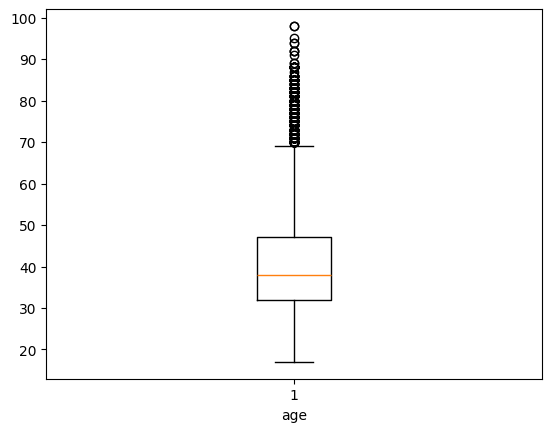

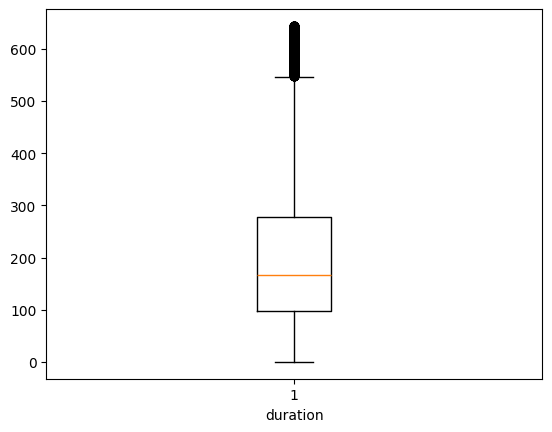

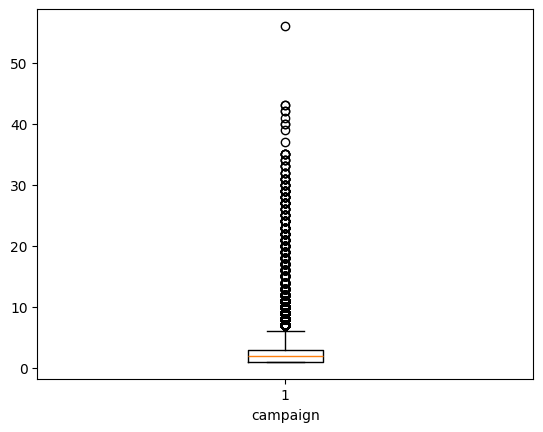

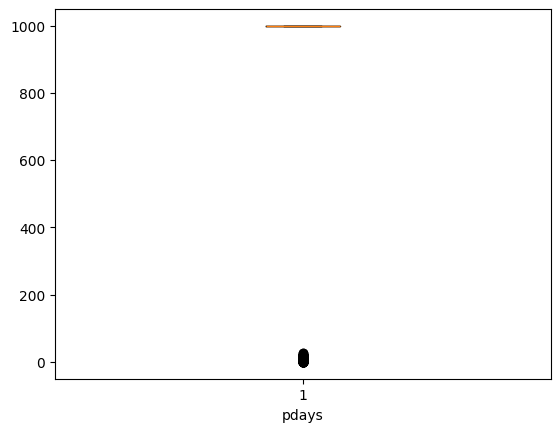

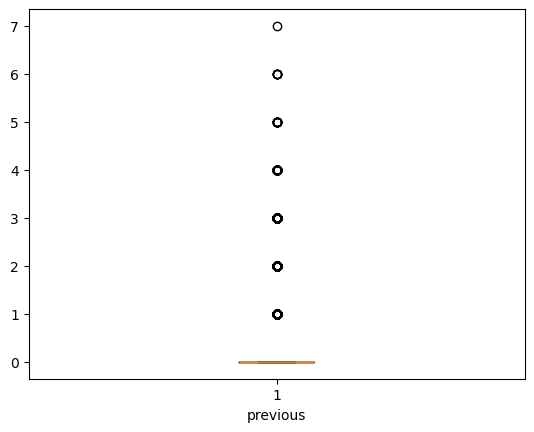

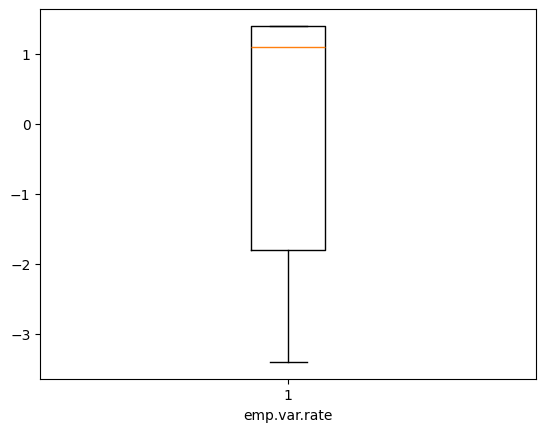

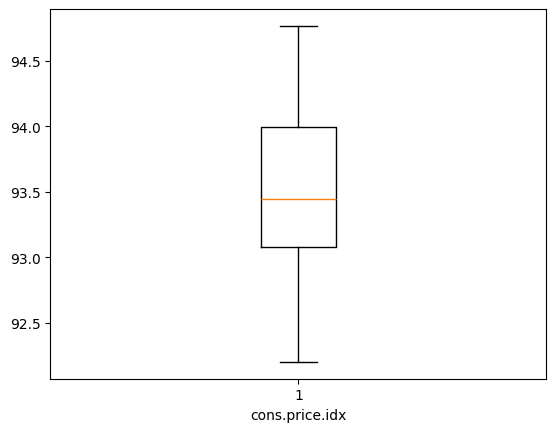

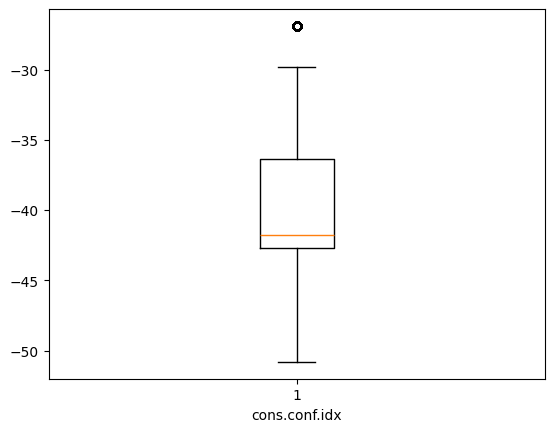

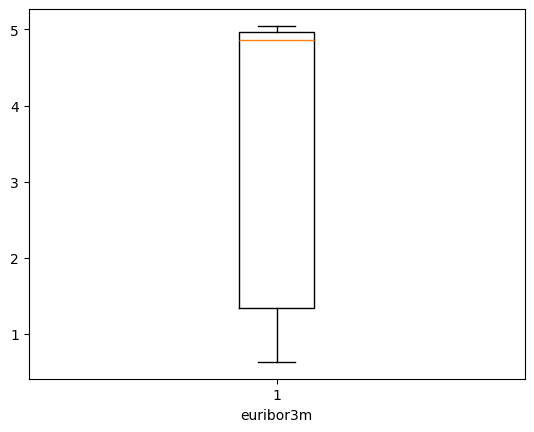

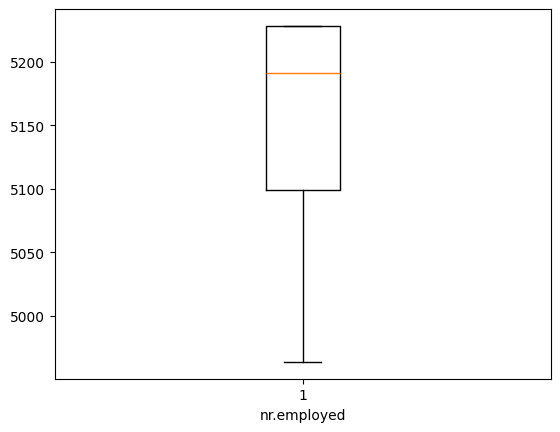

In [ ]:
for col in df.columns:
  if df[col].dtype !='object':
    plt.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38214 entries, 0 to 41193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             38214 non-null  float64
 1   job             38214 non-null  object 
 2   marital         38214 non-null  object 
 3   education       38214 non-null  object 
 4   default         38214 non-null  object 
 5   housing         38214 non-null  object 
 6   loan            38214 non-null  object 
 7   contact         38214 non-null  object 
 8   month           38214 non-null  object 
 9   day_of_week     38214 non-null  object 
 10  duration        38214 non-null  float64
 11  campaign        38214 non-null  float64
 12  pdays           38214 non-null  float64
 13  previous        38214 non-null  float64
 14  poutcome        38214 non-null  object 
 15  emp.var.rate    38214 non-null  float64
 16  cons.price.idx  38214 non-null  float64
 17  cons.conf.idx   38214 non-null  floa

# Label Encoding

In [ ]:
# label encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [ ]:
for col in df.columns:
  if df[col].dtype =='object':
    df[col] = le.fit_transform(df[col])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38214 entries, 0 to 41193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             38214 non-null  float64
 1   job             38214 non-null  int64  
 2   marital         38214 non-null  int64  
 3   education       38214 non-null  int64  
 4   default         38214 non-null  int64  
 5   housing         38214 non-null  int64  
 6   loan            38214 non-null  int64  
 7   contact         38214 non-null  int64  
 8   month           38214 non-null  int64  
 9   day_of_week     38214 non-null  int64  
 10  duration        38214 non-null  float64
 11  campaign        38214 non-null  float64
 12  pdays           38214 non-null  float64
 13  previous        38214 non-null  float64
 14  poutcome        38214 non-null  int64  
 15  emp.var.rate    38214 non-null  float64
 16  cons.price.idx  38214 non-null  float64
 17  cons.conf.idx   38214 non-null  floa

In [ ]:
# Clean data --> model building

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,3,1,0,0,0,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57.0,7,1,3,1,0,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37.0,7,1,3,0,2,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40.0,0,1,1,0,0,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56.0,7,1,3,0,0,2,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0



# Model building



In [ ]:
x = df.drop('y', axis = 1)
y = df['y']

In [ ]:
x=df.iloc[:,:-1]
y = df.iloc[:,-1]

# you can use this if the target column is in the last
#it is based on slicing [:,:-1]--first part says get all rows, second part says all columns except last
# [:,-1] -- get all rows and just the last column

In [ ]:
x

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56.0,3,1,0,0,0,0,1,6,1,261.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
1,57.0,7,1,3,1,0,0,1,6,1,149.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
2,37.0,7,1,3,0,2,0,1,6,1,226.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
3,40.0,0,1,1,0,0,0,1,6,1,151.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
4,56.0,7,1,3,0,0,2,1,6,1,307.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41184,46.0,1,1,5,0,0,0,0,7,0,383.0,1.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6
41185,56.0,5,1,6,0,2,0,0,7,0,189.0,2.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6
41186,44.0,9,1,5,0,0,0,0,7,0,442.0,1.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6
41187,74.0,5,1,5,0,2,0,0,7,0,239.0,3.0,999.0,1.0,0,-1.1,94.767,-50.8,1.028,4963.6


In [ ]:
y

,y
0,0
1,0
2,0
3,0
4,0
...,...
41184,0
41185,0
41186,1
41187,0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train, y_test = train_test_split(x,y, test_size=0.2, random_state = 7)

In [ ]:
x_train

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
18763,54.0,7,1,1,0,2,0,0,3,2,86.0,4.0,999.0,0.0,1,1.4,93.918,-42.7,4.968,5228.1
29283,39.0,1,1,0,0,2,0,0,0,0,156.0,2.0,999.0,0.0,1,-1.8,93.075,-47.1,1.405,5099.1
4401,40.0,2,1,2,1,2,2,1,6,3,246.0,3.0,999.0,0.0,1,1.1,93.994,-36.4,4.856,5191.0
20644,36.0,0,2,6,0,0,0,0,1,4,142.0,1.0,999.0,0.0,1,1.4,93.444,-36.1,4.965,5228.1
36961,43.0,9,2,6,0,0,0,0,3,2,109.0,1.0,999.0,0.0,1,-2.9,92.469,-33.6,1.072,5076.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2757,48.0,1,1,0,0,2,0,1,6,4,158.0,2.0,999.0,0.0,1,1.1,93.994,-36.4,4.859,5191.0
36788,33.0,10,1,6,0,2,0,0,4,1,579.0,3.0,999.0,0.0,1,-2.9,92.963,-40.8,1.260,5076.2
14988,36.0,1,1,2,1,2,0,0,3,2,53.0,2.0,999.0,0.0,1,1.4,93.918,-42.7,4.958,5228.1
972,33.0,6,1,2,0,2,0,1,6,4,48.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.856,5191.0


In [ ]:
x_train.shape

(30571, 20)

In [ ]:
x_test.shape

(7643, 20)

In [ ]:
y_train.shape

(30571,)

In [ ]:
y_test.shape

(7643,)

In [ ]:
y_train

,y
18763,0
29283,0
4401,0
20644,0
36961,0
...,...
2757,0
36788,1
14988,0
972,0


# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr = LogisticRegression()

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
lr.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred = lr.predict(x_test)

In [ ]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
y_pred.shape

(7643,)

In [ ]:
from sklearn.metrics import *

In [ ]:
confusion_matrix(y_test,y_pred)

array([[6878,  131],
       [ 373,  261]])

In [ ]:
test_accuracy = accuracy_score(y_test,y_pred)
test_accuracy

0.9340573073400498

In [ ]:
precision_score(y_test,y_pred)

0.6658163265306123

In [ ]:
recall_score(y_test,y_pred)

0.4116719242902208

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96      7009
           1       0.67      0.41      0.51       634

    accuracy                           0.93      7643
   macro avg       0.81      0.70      0.74      7643
weighted avg       0.93      0.93      0.93      7643



In [ ]:
# training accuracy

y_train_pred = lr.predict(x_train)

In [ ]:
y_train_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
train_accuracy = accuracy_score(y_train,y_train_pred)

In [ ]:
train_accuracy

0.9337607536554251

In [ ]:
train_accuracy, test_accuracy

(0.9337607536554251, 0.9340573073400498)

# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt_model = DecisionTreeClassifier()

In [ ]:
dt_model.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred_dt = dt_model.predict(x_test)

In [ ]:
y_pred_dt

array([1, 0, 0, ..., 0, 0, 0])

In [ ]:
dt_a = accuracy_score(y_test,y_pred_dt)

In [ ]:
dt_a

0.9182258275546251

In [ ]:
y_train_pred_dt = dt_model.predict(x_train)

In [ ]:
y_train_pred_dt

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
tr_a_dt = accuracy_score(y_train,y_train_pred_dt)

In [ ]:
tr_a_dt

1.0

In [ ]:
print("Training accuracy for dt model", tr_a_dt)
print("Testing accuaracy for dt model", dt_a)

Training accuracy for dt model 1.0
Testing accuaracy for dt model 0.9182258275546251


In [ ]:
# This is an absolute case of overfitting
# Since the data is simpler while we are using a complex model its learning the patterns way to well that it is even
# learning the noise so causing overfitting